Imports

In [ ]:
from google.colab import drive
import os
import shutil
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

mount google drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_ROOT = Path("/content/drive/MyDrive/connecthathon/Clean_Dataset")
IMAGES_ROOT = DATASET_ROOT / "Images"
LABELS_ROOT = DATASET_ROOT / "Labels"
YOLO_DATASET_ROOT = (
    DATASET_ROOT.parent / "YOLO_Dataset"
)

print(YOLO_DATASET_ROOT)
print("Dataset :", DATASET_ROOT)
print("Images  :", IMAGES_ROOT)
print("Labels  :", LABELS_ROOT)

/content/drive/MyDrive/connecthathon/YOLO_Dataset
Dataset : /content/drive/MyDrive/connecthathon/Clean_Dataset
Images  : /content/drive/MyDrive/connecthathon/Clean_Dataset/Images
Labels  : /content/drive/MyDrive/connecthathon/Clean_Dataset/Labels


In [ ]:
print("Images:")
for path in sorted(IMAGES_ROOT.iterdir()):
    print("  ", path.name)

print("\nLabels:")
for path in sorted(LABELS_ROOT.iterdir()):
    print("  ", path.name)

Images:
   no_retractors
   pilot
   retractors

Labels:
   no_retractors
   pilot
   retractors


Audit

In [ ]:

IMAGE_EXTENSIONS = {
    ".jpg",
}

image_files = [
    p for p in IMAGES_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

label_files = [
    p for p in LABELS_ROOT.rglob("*.txt")
    if p.is_file()
]

print("=" * 60)
print("DATASET AUDIT")
print("=" * 60)

print(f"Total images : {len(image_files)}")
print(f"Total labels : {len(label_files)}")

DATASET AUDIT
Total images : 2211
Total labels : 2211


In [ ]:
missing_labels = []
matched_pairs = []

for image_path in image_files:

    relative_path = image_path.relative_to(IMAGES_ROOT)
    label_relative_path = relative_path.with_suffix(".txt")

    label_path = LABELS_ROOT / label_relative_path

    if label_path.exists():
        matched_pairs.append((image_path, label_path))
    else:
        missing_labels.append(image_path)

print(f"Matched image/label pairs : {len(matched_pairs)}")
print(f"Images without label      : {len(missing_labels)}")

Matched image/label pairs : 2211
Images without label      : 0


In [ ]:
positive_images = 0
negative_images = 0
total_boxes = 0

invalid_files = []
invalid_lines = []

class_counts = {}

for image_path, label_path in matched_pairs:

    content = label_path.read_text(
        encoding="utf-8",
        errors="replace"
    ).strip()

    # Empty label = negative image
    if not content:
        negative_images += 1
        continue

    lines = content.splitlines()

    image_has_valid_box = False

    for line_number, line in enumerate(lines, start=1):

        parts = line.strip().split()

        if len(parts) != 5:
            invalid_lines.append(
                (label_path, line_number, line)
            )
            continue

        try:
            class_id = int(parts[0])
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])
        except ValueError:
            invalid_lines.append(
                (label_path, line_number, line)
            )
            continue

        valid = (
            class_id >= 0
            and 0 <= x_center <= 1
            and 0 <= y_center <= 1
            and 0 < width <= 1
            and 0 < height <= 1
        )

        if not valid:
            invalid_lines.append(
                (label_path, line_number, line)
            )
            continue

        image_has_valid_box = True
        total_boxes += 1

        class_counts[class_id] = (
            class_counts.get(class_id, 0) + 1
        )

    if image_has_valid_box:
        positive_images += 1


print("=" * 60)
print("YOLO ANNOTATION AUDIT")
print("=" * 60)

print(f"Positive images       : {positive_images}")
print(f"Negative images       : {negative_images}")
print(f"Total bounding boxes  : {total_boxes}")
print(f"Invalid annotation lines : {len(invalid_lines)}")

print("\nClass distribution:")
for class_id, count in sorted(class_counts.items()):
    print(f"  Class {class_id}: {count} boxes")

YOLO ANNOTATION AUDIT
Positive images       : 2148
Negative images       : 63
Total bounding boxes  : 6686
Invalid annotation lines : 0

Class distribution:
  Class 0: 6134 boxes
  Class 1: 552 boxes


In [ ]:
image_stems = {
    p.relative_to(IMAGES_ROOT).with_suffix(".txt")
    for p in image_files
}

orphan_labels = []

for label_path in label_files:

    relative_label = label_path.relative_to(LABELS_ROOT)

    if relative_label not in image_stems:
        orphan_labels.append(label_path)

print("=" * 60)
print("ORPHAN LABEL AUDIT")
print("=" * 60)

print(f"Orphan labels : {len(orphan_labels)}")

ORPHAN LABEL AUDIT
Orphan labels : 0


In [ ]:
print()
print("=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

print(f"Images                  : {len(image_files)}")
print(f"YOLO label files        : {len(label_files)}")
print(f"Matched pairs           : {len(matched_pairs)}")
print(f"Missing labels          : {len(missing_labels)}")
print(f"Orphan labels           : {len(orphan_labels)}")
print(f"Positive images         : {positive_images}")
print(f"Negative images         : {negative_images}")
print(f"Bounding boxes          : {total_boxes}")
print(f"Invalid annotation lines: {len(invalid_lines)}")

print()
print("Classes:")
for class_id, count in sorted(class_counts.items()):
    print(f"  {class_id}: {count} boxes")


FINAL DATASET SUMMARY
Images                  : 2211
YOLO label files        : 2211
Matched pairs           : 2211
Missing labels          : 0
Orphan labels           : 0
Positive images         : 2148
Negative images         : 63
Bounding boxes          : 6686
Invalid annotation lines: 0

Classes:
  0: 6134 boxes
  1: 552 boxes


Show samples

In [ ]:
def show_image_with_boxes(
    name,
    group,
    angle,
    figsize=(12, 8)
):
    # --------------------------------------------------------
    # 1. Construire le nom du fichier
    # --------------------------------------------------------

    image_name = Path(name)

    if image_name.suffix == "":
        image_name = image_name.with_suffix(".jpg")

    # --------------------------------------------------------
    # 2. Construire les chemins
    # --------------------------------------------------------

    image_path = (
        IMAGES_ROOT
        / group
        / angle
        / image_name
    )

    label_path = (
        LABELS_ROOT
        / group
        / angle
        / image_name.with_suffix(".txt").name
    )

    # --------------------------------------------------------
    # 3. Vérifier les fichiers
    # --------------------------------------------------------

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image not found:\n{image_path}"
        )

    if not label_path.exists():
        raise FileNotFoundError(
            f"Label not found:\n{label_path}"
        )

    # --------------------------------------------------------
    # 4. Charger l'image
    # --------------------------------------------------------

    image = Image.open(image_path).convert("RGB")

    image_width, image_height = image.size

    # --------------------------------------------------------
    # 5. Lire les annotations
    # --------------------------------------------------------

    boxes = []

    content = label_path.read_text(
        encoding="utf-8"
    ).strip()

    if content:

        for line in content.splitlines():

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])

            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            # ------------------------------------------------
            # YOLO normalized coordinates
            # → pixel coordinates
            # ------------------------------------------------

            box_width = width * image_width
            box_height = height * image_height

            x_center_pixel = x_center * image_width
            y_center_pixel = y_center * image_height

            xmin = x_center_pixel - box_width / 2
            ymin = y_center_pixel - box_height / 2

            xmax = x_center_pixel + box_width / 2
            ymax = y_center_pixel + box_height / 2

            boxes.append(
                (
                    class_id,
                    xmin,
                    ymin,
                    xmax,
                    ymax
                )
            )

    # --------------------------------------------------------
    # 6. Affichage
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(image)

    for class_id, xmin, ymin, xmax, ymax in boxes:

        rectangle = plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        ax.text(
            xmin,
            max(0, ymin - 5),
            f"Class {class_id}",
            fontsize=10,
            backgroundcolor="white"
        )

    ax.set_title(
        f"{group} / {angle} / {image_name.name}\n"
        f"{len(boxes)} bounding box(es)"
    )

    ax.axis("off")

    plt.show()

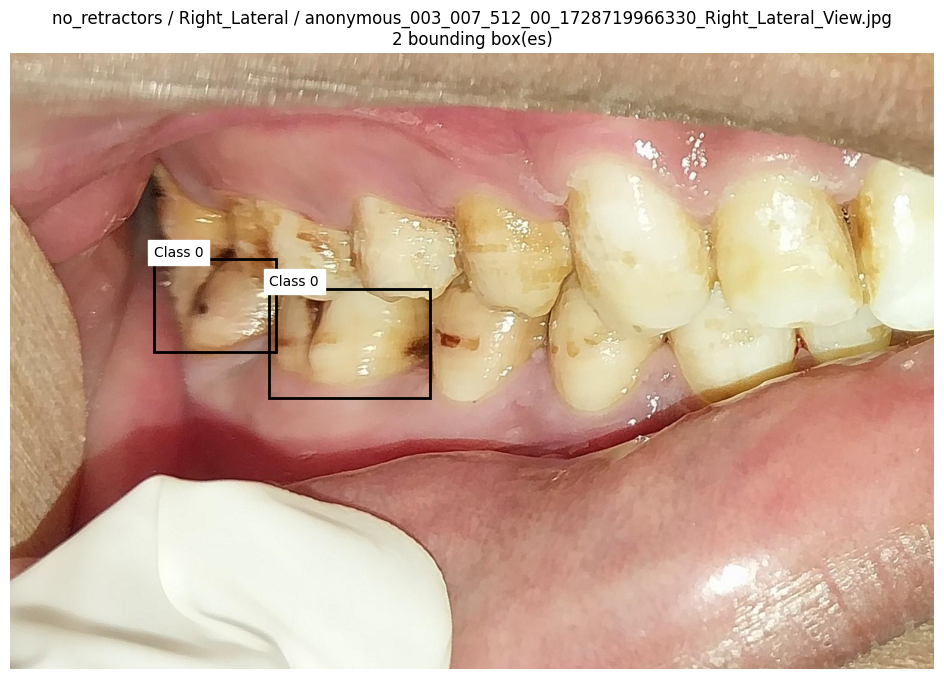

In [ ]:
show_image_with_boxes(
    name="anonymous_003_007_512_00_1728719966330_Right_Lateral_View.jpg",
    group="no_retractors",
    angle="Right_Lateral"
)

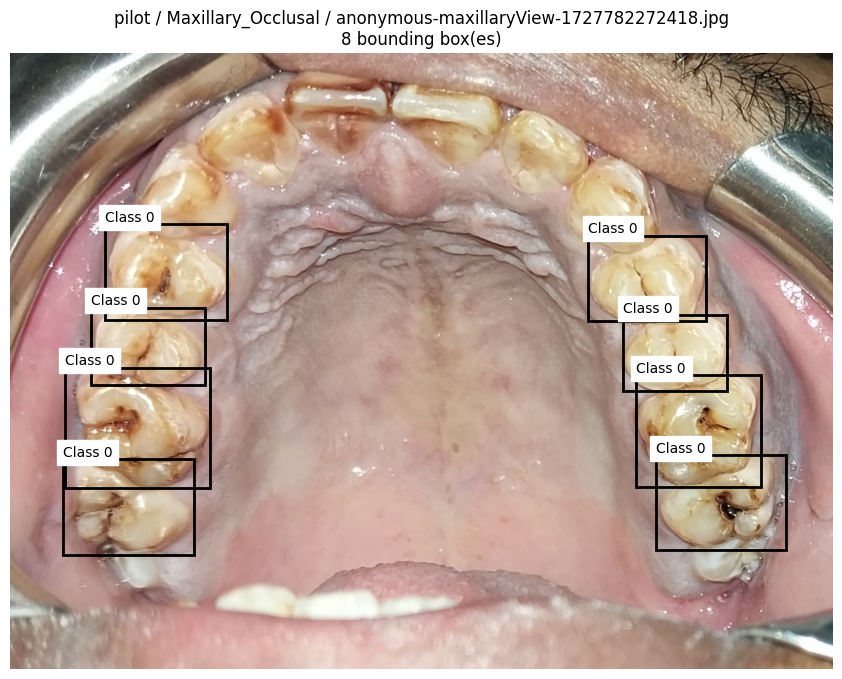

In [ ]:
show_image_with_boxes(
    name="anonymous-maxillaryView-1727782272418.jpg",
    group="pilot",
    angle="Maxillary_Occlusal"
)

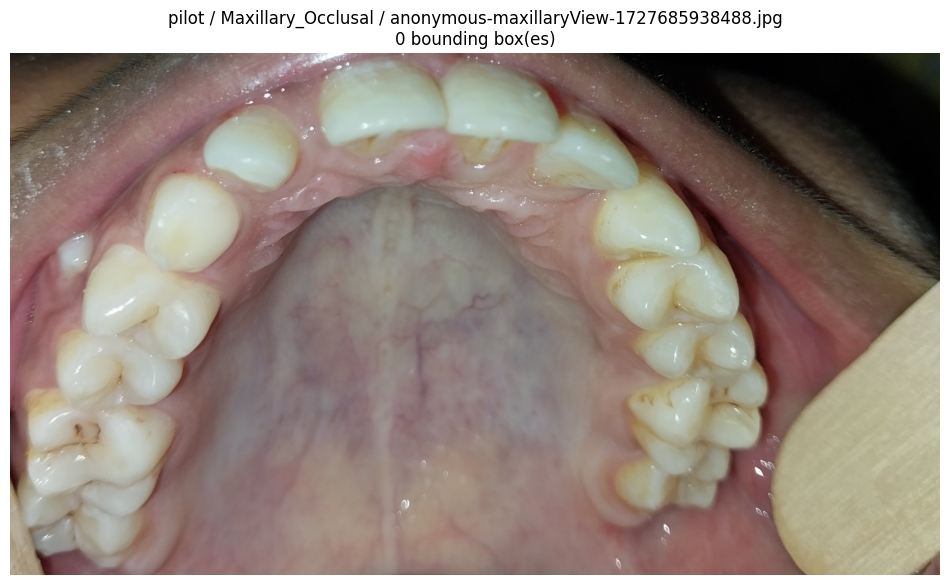

In [ ]:
show_image_with_boxes(
    name="anonymous-maxillaryView-1727685938488.jpg",
    group="pilot",
    angle="Maxillary_Occlusal"
)

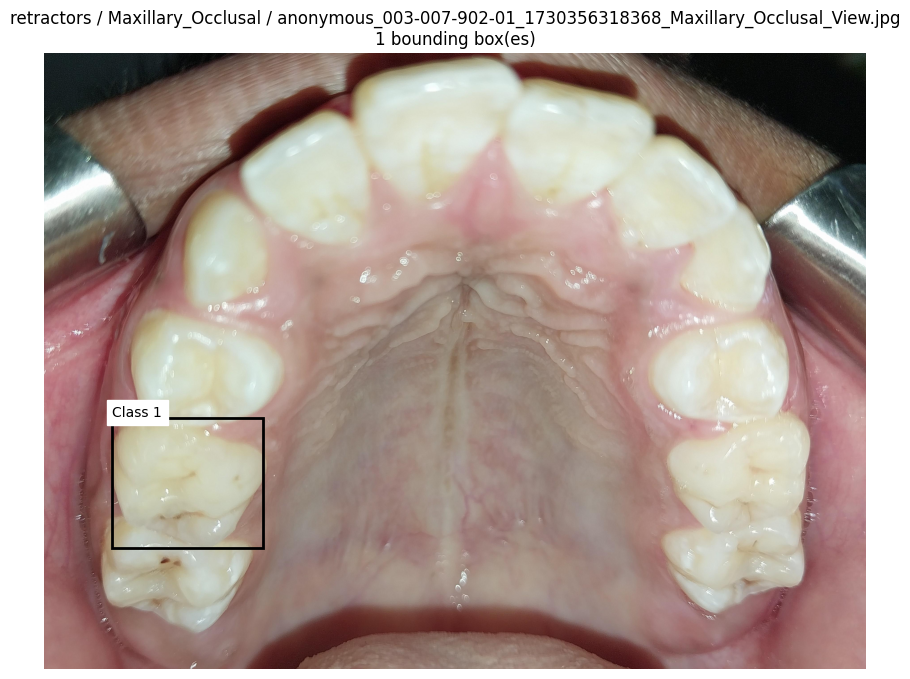

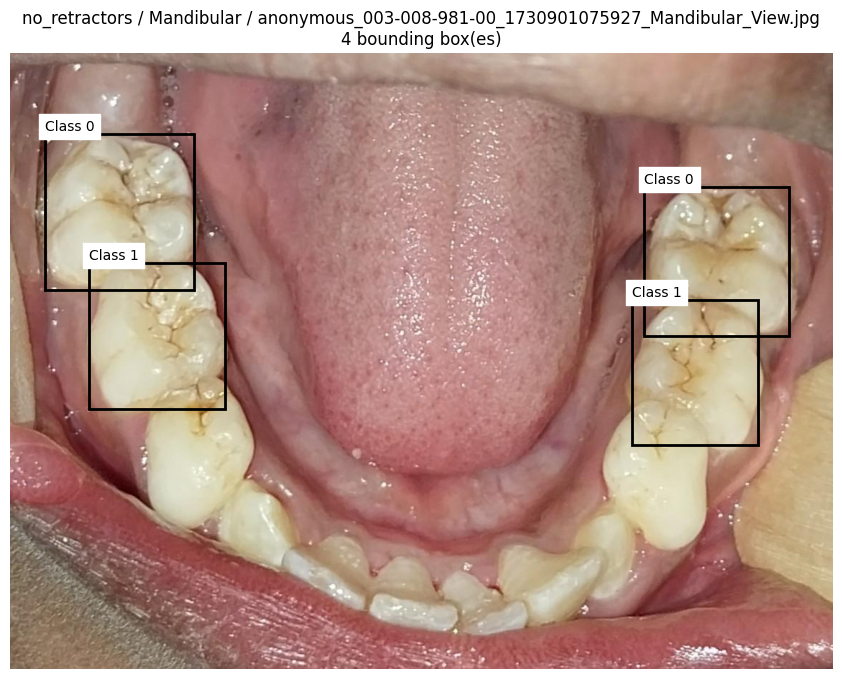

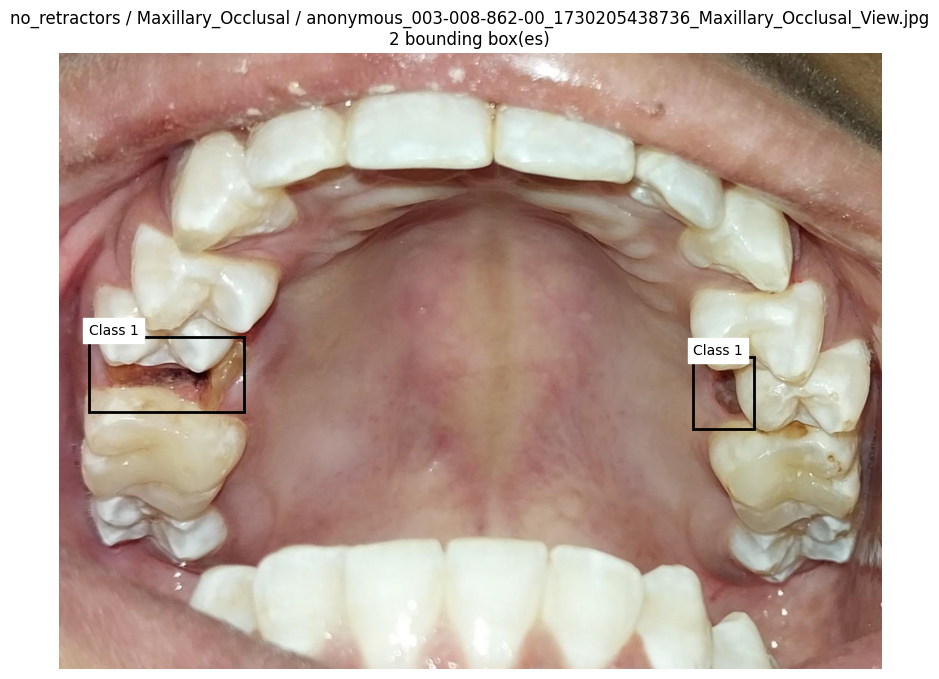

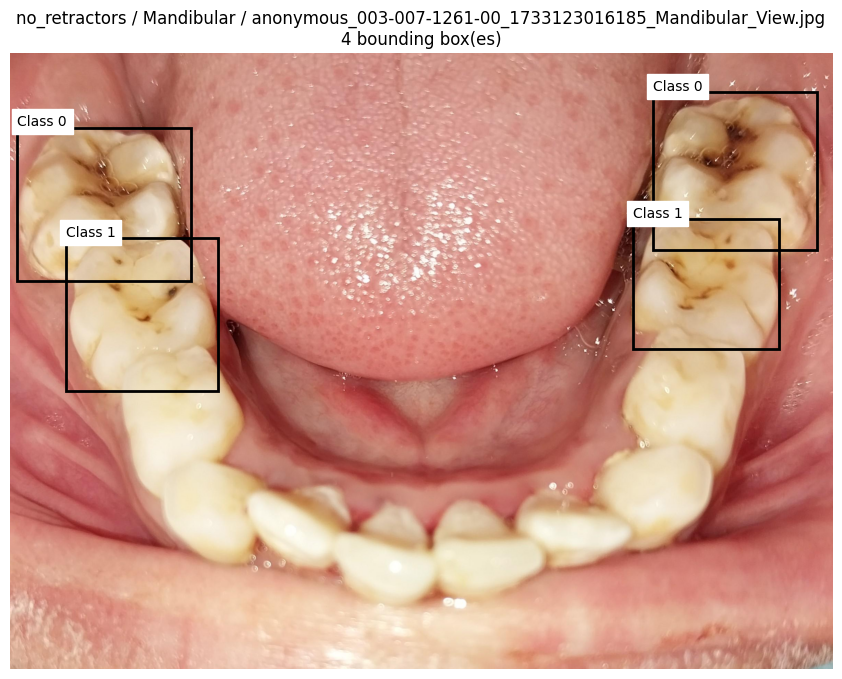

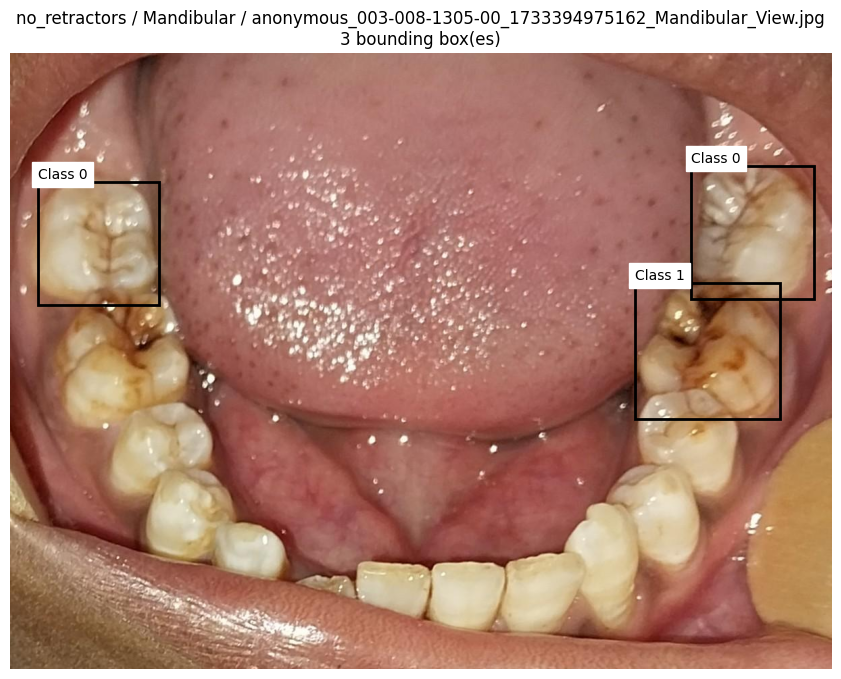

In [ ]:
def show_random_image_by_class(
    class_id,
    n=1,
    group=None,
    angle=None,
    figsize=(12, 8)
):
    """
    Display random images containing a specific YOLO class.

    Parameters
    ----------
    class_id : int
        Class to search for. Example: 1

    n : int
        Number of images to display.

    group : str or None
        Restrict search to a specific group.

    angle : str or None
        Restrict search to a specific angle.

    figsize : tuple
        Matplotlib figure size.
    """

    # --------------------------------------------------------
    # Search root
    # --------------------------------------------------------

    if group is None:
        search_root = IMAGES_ROOT
    else:
        search_root = IMAGES_ROOT / group

    # --------------------------------------------------------
    # Find images
    # --------------------------------------------------------

    candidates = []

    for image_path in search_root.rglob("*"):

        if not image_path.is_file():
            continue

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        # Filter angle
        if angle is not None and angle not in image_path.parts:
            continue

        relative_path = image_path.relative_to(IMAGES_ROOT)

        label_path = (
            LABELS_ROOT
            / relative_path.with_suffix(".txt")
        )

        if not label_path.exists():
            continue

        # ----------------------------------------------------
        # Read label
        # ----------------------------------------------------

        content = label_path.read_text(
            encoding="utf-8",
            errors="replace"
        ).strip()

        if not content:
            continue

        # ----------------------------------------------------
        # Check class
        # ----------------------------------------------------

        contains_class = False

        for line in content.splitlines():

            parts = line.split()

            if len(parts) != 5:
                continue

            try:
                current_class = int(parts[0])
            except ValueError:
                continue

            if current_class == class_id:
                contains_class = True
                break

        if contains_class:
            candidates.append(image_path)

    # --------------------------------------------------------
    # No results
    # --------------------------------------------------------

    if not candidates:
        print(f"No image found containing class {class_id}.")
        return

    # --------------------------------------------------------
    # Random selection
    # --------------------------------------------------------

    n = min(n, len(candidates))

    selected_images = random.sample(
        candidates,
        n
    )

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    for image_path in selected_images:

        relative_path = image_path.relative_to(IMAGES_ROOT)

        group_name = relative_path.parts[0]
        angle_name = relative_path.parts[1]

        show_image_with_boxes(
            name=image_path.name,
            group=group_name,
            angle=angle_name,
            figsize=figsize
        )

show_random_image_by_class(
    class_id=1,
    n=5
)

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image


def show_random_image(
    group=None,
    angle=None,
    figsize=(12, 8)
):

    # --------------------------------------------------------
    # Select search root
    # --------------------------------------------------------

    if group is None:
        search_root = IMAGES_ROOT
    else:
        search_root = IMAGES_ROOT / group

    # --------------------------------------------------------
    # Find images
    # --------------------------------------------------------

    candidates = [
        p for p in search_root.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Filter by angle if specified
    if angle is not None:
        candidates = [
            p for p in candidates
            if angle in p.parts
        ]

    if not candidates:
        print("No images found.")
        return

    # --------------------------------------------------------
    # Random image
    # --------------------------------------------------------

    image_path = random.choice(candidates)

    # Relative path
    relative_path = image_path.relative_to(IMAGES_ROOT)

    # Corresponding label
    label_path = (
        LABELS_ROOT
        / relative_path.with_suffix(".txt")
    )

    # --------------------------------------------------------
    # Display using our previous function
    # --------------------------------------------------------

    show_image_with_boxes(
        name=image_path.name,
        group=image_path.parent.parent.name,
        angle=image_path.parent.name,
        figsize=figsize
    )

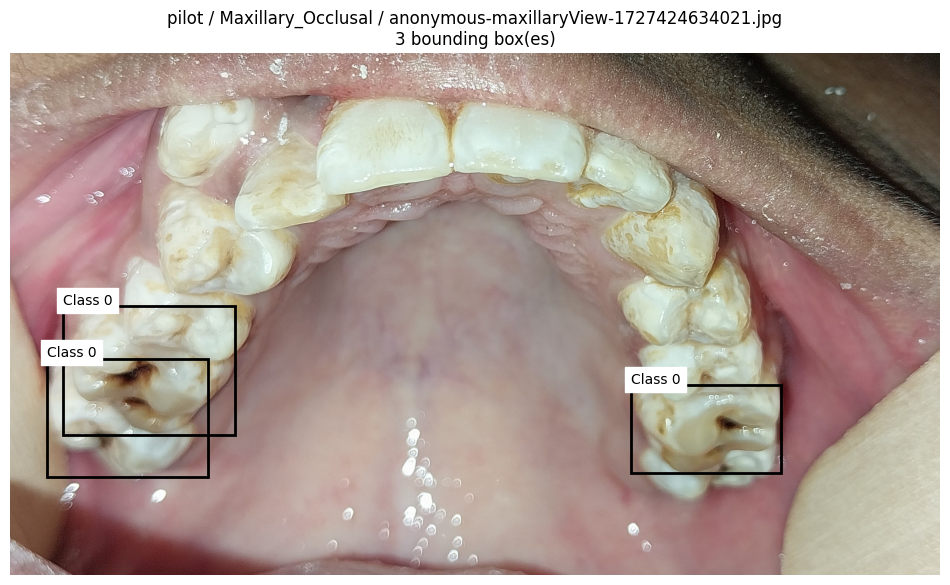

In [ ]:
show_random_image()

In [ ]:
def build_dataset_metadata(images_root, labels_root):
    """
    Build a metadata DataFrame for the cleaned YOLO dataset.

    Each row corresponds to one image and contains:
    - image name
    - relative image path
    - group
    - angle
    - classes present
    - class signature
    - positive/negative status
    - number of bounding boxes
    """

    images_root = Path(images_root)
    labels_root = Path(labels_root)

    records = []

    for image_path in sorted(images_root.rglob("*.jpg")):

        # Relative path: group / angle / image.jpg
        relative_path = image_path.relative_to(images_root)

        parts = relative_path.parts

        if len(parts) < 3:
            print(f"Skipping unexpected path: {image_path}")
            continue

        group = parts[0]
        angle = parts[1]

        # Corresponding label
        label_path = labels_root / relative_path.with_suffix(".txt")

        classes = []
        num_boxes = 0

        if label_path.exists():

            with open(label_path, "r") as f:
                for line in f:
                    line = line.strip()

                    if not line:
                        continue

                    values = line.split()

                    # Valid YOLO line should contain:
                    # class_id + 4 coordinates
                    if len(values) != 5:
                        continue

                    try:
                        class_id = int(values[0])
                        classes.append(class_id)
                        num_boxes += 1
                    except ValueError:
                        continue

        # Unique classes present in the image
        unique_classes = sorted(set(classes))

        # Class signature
        if len(unique_classes) == 0:
            class_signature = "none"
        else:
            class_signature = "_".join(map(str, unique_classes))

        records.append({
            "image": image_path.name,
            "relative_path": str(relative_path),
            "group": group,
            "angle": angle,
            "classes": class_signature,
            "positive": num_boxes > 0,
            "num_boxes": num_boxes
        })

    df = pd.DataFrame(records)

    return df

In [ ]:
df_metadata = build_dataset_metadata(
    IMAGES_ROOT,
    LABELS_ROOT
)

print(f"Number of images: {len(df_metadata)}")

display(df_metadata.head(10))

Number of images: 2211


,image,relative_path,group,angle,classes,positive,num_boxes
0,anonymous_003-007-673-00_1729239709286_Frontal...,no_retractors/Frontal/anonymous_003-007-673-00...,no_retractors,Frontal,1,True,1
1,anonymous_003-007-848-00_1730185308013_Frontal...,no_retractors/Frontal/anonymous_003-007-848-00...,no_retractors,Frontal,1,True,1
2,anonymous_003-007-870-00_1730264018655_Frontal...,no_retractors/Frontal/anonymous_003-007-870-00...,no_retractors,Frontal,0,True,1
3,anonymous_003-007-950-00_1730792603619_Frontal...,no_retractors/Frontal/anonymous_003-007-950-00...,no_retractors,Frontal,1,True,1
4,anonymous_003-008-1052-00_1731329608354_Fronta...,no_retractors/Frontal/anonymous_003-008-1052-0...,no_retractors,Frontal,0,True,1
5,anonymous_003-008-1134-00_1732531184012_Fronta...,no_retractors/Frontal/anonymous_003-008-1134-0...,no_retractors,Frontal,0,True,1
6,anonymous_003-008-1140-00_1732538036389_Fronta...,no_retractors/Frontal/anonymous_003-008-1140-0...,no_retractors,Frontal,none,False,0
7,anonymous_003-008-563-00_1728904641646_Frontal...,no_retractors/Frontal/anonymous_003-008-563-00...,no_retractors,Frontal,0,True,1
8,anonymous_003-008-621-00_1729084830092_Frontal...,no_retractors/Frontal/anonymous_003-008-621-00...,no_retractors,Frontal,0,True,3
9,anonymous_003-008-625-00_1729089968039_Frontal...,no_retractors/Frontal/anonymous_003-008-625-00...,no_retractors,Frontal,none,False,0


In [ ]:
df_metadata["stratum"] = (
    df_metadata["group"] + "__" +
    df_metadata["angle"] + "__" +
    df_metadata["classes"]
)

print("Number of strata:", df_metadata["stratum"].nunique())

display(
    df_metadata["stratum"]
    .value_counts()
    .sort_index()
)

Number of strata: 52


,count
stratum,
no_retractors__Frontal__0,7
no_retractors__Frontal__1,4
no_retractors__Frontal__none,3
no_retractors__Left_Lateral__0,27
no_retractors__Left_Lateral__1,9
no_retractors__Left_Lateral__none,4
no_retractors__Mandibular__0,415
no_retractors__Mandibular__0_1,64
no_retractors__Mandibular__1,15


In [ ]:
def prepare_split_strata(df):
    """
    Prepare a simplified stratification key for dataset splitting.

    The split is stratified by:
    - group
    - acquisition angle

    Class distribution will be checked separately after splitting.
    """

    df = df.copy()

    df["split_stratum"] = (
        df["group"] + "__" + df["angle"]
    )

    return df

df_metadata = prepare_split_strata(df_metadata)

print("Number of simplified strata:", df_metadata["split_stratum"].nunique())

display(
    df_metadata["split_stratum"]
    .value_counts()
    .sort_index()
)

Number of simplified strata: 15


,count
split_stratum,
no_retractors__Frontal,14
no_retractors__Left_Lateral,40
no_retractors__Mandibular,495
no_retractors__Maxillary_Occlusal,372
no_retractors__Right_Lateral,44
pilot__Frontal,17
pilot__Left_Lateral,15
pilot__Mandibular,128
pilot__Maxillary_Occlusal,88


Split data

In [ ]:
def split_dataset(df, train_size=0.70, val_size=0.15, test_size=0.15, seed=42):
    """
    Split the dataset into train, validation and test sets.

    Stratification is based only on:
        group + angle

    The split is performed in two stages:
        1. Train vs temporary set
        2. Validation vs test
    """

    if abs(train_size + val_size + test_size - 1.0) > 1e-6:
        raise ValueError("train_size + val_size + test_size must equal 1.")

    df = df.copy()

    # Create stratification key
    df["split_stratum"] = (
        df["group"] + "__" + df["angle"]
    )

    # --------------------------------------------------
    # First split: Train / Temporary
    # --------------------------------------------------

    train_df, temp_df = train_test_split(
        df,
        test_size=(val_size + test_size),
        stratify=df["split_stratum"],
        random_state=seed
    )

    # --------------------------------------------------
    # Second split: Validation / Test
    # --------------------------------------------------

    # Relative proportion of validation inside temp
    val_ratio_in_temp = val_size / (val_size + test_size)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - val_ratio_in_temp),
        stratify=temp_df["split_stratum"],
        random_state=seed
    )

    # Remove helper column
    train_df = train_df.drop(columns=["split_stratum"])
    val_df = val_df.drop(columns=["split_stratum"])
    test_df = test_df.drop(columns=["split_stratum"])

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True)
    )

In [ ]:
train_df, val_df, test_df = split_dataset(
    df_metadata,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    seed=42
)

print(f"Train:      {len(train_df)} images")
print(f"Validation: {len(val_df)} images")
print(f"Test:       {len(test_df)} images")

print(f"\nTotal:      {len(train_df) + len(val_df) + len(test_df)} images")

Train:      1547 images
Validation: 332 images
Test:       332 images

Total:      2211 images


In [ ]:
def show_split_distribution(train_df, val_df, test_df):
    """
    Display group + angle distribution for each split.
    """

    splits = {
        "Train": train_df,
        "Validation": val_df,
        "Test": test_df
    }

    for name, df in splits.items():

        print(f"\n{'=' * 50}")
        print(f"{name.upper()} - {len(df)} images")
        print(f"{'=' * 50}")

        distribution = (
            df.groupby(["group", "angle"])
              .size()
              .reset_index(name="count")
        )

        display(distribution)


show_split_distribution(
    train_df,
    val_df,
    test_df
)


TRAIN - 1547 images


,group,angle,count
0,no_retractors,Frontal,10
1,no_retractors,Left_Lateral,28
2,no_retractors,Mandibular,346
3,no_retractors,Maxillary_Occlusal,260
4,no_retractors,Right_Lateral,31
5,pilot,Frontal,12
6,pilot,Left_Lateral,11
7,pilot,Mandibular,90
8,pilot,Maxillary_Occlusal,62
9,pilot,Right_Lateral,15



VALIDATION - 332 images


,group,angle,count
0,no_retractors,Frontal,2
1,no_retractors,Left_Lateral,6
2,no_retractors,Mandibular,74
3,no_retractors,Maxillary_Occlusal,56
4,no_retractors,Right_Lateral,7
5,pilot,Frontal,3
6,pilot,Left_Lateral,2
7,pilot,Mandibular,19
8,pilot,Maxillary_Occlusal,13
9,pilot,Right_Lateral,3



TEST - 332 images


,group,angle,count
0,no_retractors,Frontal,2
1,no_retractors,Left_Lateral,6
2,no_retractors,Mandibular,75
3,no_retractors,Maxillary_Occlusal,56
4,no_retractors,Right_Lateral,6
5,pilot,Frontal,2
6,pilot,Left_Lateral,2
7,pilot,Mandibular,19
8,pilot,Maxillary_Occlusal,13
9,pilot,Right_Lateral,4


In [ ]:
import shutil
from pathlib import Path


def create_yolo_dataset(
    train_df,
    val_df,
    test_df,
    images_root,
    labels_root,
    output_root
):
    """
    Create a YOLO-compatible dataset from train/val/test DataFrames.

    Original Clean_Dataset is not modified.
    Images and labels are copied into the new structure.
    """

    images_root = Path(images_root)
    labels_root = Path(labels_root)
    output_root = Path(output_root)

    # --------------------------------------------------
    # Create directory structure
    # --------------------------------------------------

    for split in ["train", "val", "test"]:
        (output_root / "images" / split).mkdir(
            parents=True,
            exist_ok=True
        )

        (output_root / "labels" / split).mkdir(
            parents=True,
            exist_ok=True
        )

    split_data = {
        "train": train_df,
        "val": val_df,
        "test": test_df
    }

    copied_images = 0
    copied_labels = 0

    # --------------------------------------------------
    # Copy images and labels
    # --------------------------------------------------

    for split, df in split_data.items():

        for _, row in df.iterrows():

            # Original paths
            image_path = images_root / row["relative_path"]
            label_path = labels_root / Path(row["relative_path"]).with_suffix(".txt")

            # Create unique filename
            original_name = image_path.stem
            extension = image_path.suffix

            unique_name = (
                f"{row['group']}__"
                f"{row['angle']}__"
                f"{original_name}"
            )

            new_image_name = unique_name + extension
            new_label_name = unique_name + ".txt"

            # Destination paths
            destination_image = (
                output_root / "images" / split / new_image_name
            )

            destination_label = (
                output_root / "labels" / split / new_label_name
            )

            # Copy image
            shutil.copy2(
                image_path,
                destination_image
            )

            copied_images += 1

            # Copy label
            if label_path.exists():

                shutil.copy2(
                    label_path,
                    destination_label
                )

                copied_labels += 1

    print("YOLO dataset created successfully.")
    print(f"Images copied: {copied_images}")
    print(f"Labels copied: {copied_labels}")
    print(f"Output directory: {output_root}")

In [ ]:
create_yolo_dataset(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    images_root=IMAGES_ROOT,
    labels_root=LABELS_ROOT,
    output_root=YOLO_DATASET_ROOT
)

YOLO dataset created successfully.
Images copied: 2211
Labels copied: 2211
Output directory: /content/drive/MyDrive/connecthathon/YOLO_Dataset


In [ ]:
for split in ["train", "val", "test"]:

    images_dir = YOLO_DATASET_ROOT / "images" / split
    labels_dir = YOLO_DATASET_ROOT / "labels" / split

    num_images = len(list(images_dir.glob("*.jpg")))
    num_labels = len(list(labels_dir.glob("*.txt")))

    print(
        f"{split:5s} | "
        f"images: {num_images:4d} | "
        f"labels: {num_labels:4d}"
    )

train | images: 1547 | labels: 1547
val   | images:  332 | labels:  332
test  | images:  332 | labels:  332


In [ ]:
for split in ["train", "val", "test"]:

    images = {
        p.stem
        for p in (YOLO_DATASET_ROOT / "images" / split).glob("*.jpg")
    }

    labels = {
        p.stem
        for p in (YOLO_DATASET_ROOT / "labels" / split).glob("*.txt")
    }

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Missing labels:", len(images - labels))
    print("Orphan labels:", len(labels - images))


TRAIN
Images: 1547
Labels: 1547
Missing labels: 0
Orphan labels: 0

VAL
Images: 332
Labels: 332
Missing labels: 0
Orphan labels: 0

TEST
Images: 332
Labels: 332
Missing labels: 0
Orphan labels: 0


In [ ]:
def merge_classes_to_single_class(dataset_root):
    """
    Merge all classes into a single class.

    Class 0 -> class 0
    Class 1 -> class 0
    """

    dataset_root = Path(dataset_root)

    total_files = 0
    total_boxes = 0

    for split in ["train", "val", "test"]:

        labels_dir = dataset_root / "labels" / split

        for label_path in labels_dir.glob("*.txt"):

            new_lines = []

            with open(label_path, "r") as f:

                for line in f:
                    line = line.strip()

                    # Keep empty label files for negative images
                    if not line:
                        continue

                    values = line.split()

                    if len(values) != 5:
                        continue

                    # Merge class 0 and class 1
                    values[0] = "0"

                    new_lines.append(" ".join(values))
                    total_boxes += 1

            # Rewrite the label file
            with open(label_path, "w") as f:
                f.write("\n".join(new_lines))

            total_files += 1

    print("Classes merged successfully.")
    print(f"Label files processed: {total_files}")
    print(f"Bounding boxes processed: {total_boxes}")

In [ ]:
merge_classes_to_single_class(YOLO_DATASET_ROOT)

Classes merged successfully.
Label files processed: 2211
Bounding boxes processed: 6686


create data.yaml

In [ ]:
data_yaml_path = YOLO_DATASET_ROOT / "data.yaml"

data_yaml_content = f"""
path: {YOLO_DATASET_ROOT}

train: images/train
val: images/val
test: images/test

names:
  0: caries
"""

with open(data_yaml_path, "w") as f:
    f.write(data_yaml_content.strip())

print(f"data.yaml created at:")
print(data_yaml_path)

data.yaml created at:
/content/drive/MyDrive/connecthathon/YOLO_Dataset/data.yaml


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 6.9 MB/s eta 0:00:00


In [ ]:
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.154


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print(model.info())
print("Task:", model.task)
print("Model:", model.model.yaml.get("yaml_file", "YOLOv8n"))

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
(129, 3157200, 0, 8.8550912)
Task: detect
Model: YOLOv8n


train the model

In [ ]:
results = model.train(
    data=str(YOLO_DATASET_ROOT / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project=str(YOLO_DATASET_ROOT / "runs"),
    name="caries_yolov8n_baseline"
)

Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/connecthathon/YOLO_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=caries_yolov8n_b

In [ ]:
from ultralytics import YOLO
from pathlib import Path

RUN_DIR = Path(
    "/content/drive/MyDrive/connecthathon/YOLO_Dataset/"
    "runs/caries_yolov8n_baseline"
)

BEST_MODEL = RUN_DIR / "weights" / "best.pt"
DATA_YAML = Path(
    "/content/drive/MyDrive/connecthathon/YOLO_Dataset/data.yaml"
)

model = YOLO(str(BEST_MODEL))

In [ ]:
test_results = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    device=0
)

Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 114.2±23.8 MB/s, size: 130.8 KB)
val: Scanning /content/drive/MyDrive/connecthathon/YOLO_Dataset/labels/test... 332 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 332/332 166.0it/s 2.0s
val: New cache created: /content/drive/MyDrive/connecthathon/YOLO_Dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 2.4it/s 8.6s
                   all        332       1061      0.853       0.91      0.944      0.743
Speed: 2.1ms preprocess, 6.0ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
print("Precision :", test_results.box.mp)
print("Recall    :", test_results.box.mr)
print("mAP50     :", test_results.box.map50)
print("mAP50-95  :", test_results.box.map)

Precision : 0.8532917229950413
Recall    : 0.909988114286178
mAP50     : 0.9440921338929741
mAP50-95  : 0.7429988876870494
